# Cohen pairwise CRE power analysis — MWU

Measures MWU test power for **pairwise CRE comparisons** as a function of
(baseline activity, fold change) in the Cohen (episomal, retinal) dataset.

Cohen is episomal: the same CREs are transfected into all cell types.
Each simulation includes all cell types together, with identical
CRE activities across cell types.

Compare with the Shendure (integrating) pairwise power analysis to see
how power differs between the two regimes.

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import uuid
import pickle
import json

%load_ext autoreload
%autoreload 2

In [2]:
data_root = Path("/gpfs/gibbs/pi/reilly/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sim_date = "2026-03-24"

In [3]:
local = False
if local:
    from dask.distributed import LocalCluster
    cluster = LocalCluster(memory_limit="48G")
    client = Client(cluster)
else:
    cluster = SLURMCluster(
        cores=1,
        memory="64G",
        processes=1,
        job_extra_directives=[
            "-p ycga",
            "--job-name=simclust_worker",
            "--time=6:00:00",
            "--output=worker_%j.out"
        ]
    )
    cluster.scale(jobs=12)
    client = Client(
        cluster,
        timeout=f"{5*60}s",
        heartbeat_interval="20s"
    )
print(client.dashboard_link, flush=True)

http://10.178.138.9:8787/status


In [4]:
# Cohen is episomal: same CREs in all cell types.
# Verify n_cres is uniform, then load activity range from fitted params.
cohen_data = pd.read_parquet(
    data_root / "cohen_ortho" / "retina_single_counting_u6.scmpra",
    columns=["cell_type", "cre_id"]
)
n_cres_by_ct = cohen_data.groupby("cell_type")["cre_id"].nunique()
print("n_cres per cell type (should be uniform):")
print(n_cres_by_ct)
assert n_cres_by_ct.nunique() == 1, "n_cres not uniform!"

n_cres = int(n_cres_by_ct.iloc[0])
cell_types = list(scm.COHEN_BOUNDS.cells_per_cell_type.index)
del cohen_data

# Activity range from fitted ortho parameters
with open(data_root / "cohen_ortho" / "by_cell_type_parameters.pkl", "rb") as f:
    _params = pickle.load(f)
all_mus = np.concatenate([_params.nb[ct]["mu"].values for ct in _params.nb])
mu_min, mu_max = float(all_mus.min()), float(all_mus.max())
del _params

print(f"n_cres={n_cres}, cell_types={cell_types}")
print(f"Observed mu range: [{mu_min:.4f}, {mu_max:.4f}]")
for ct in cell_types:
    cells_ct = scm.COHEN_BOUNDS.cells_per_cell_type.get(ct, "?")
    print(f"  {ct}: cells={cells_ct}")

n_cres per cell type (should be uniform):
cell_type
Bipolar         115
Interneuron     115
Mueller Glia    115
Rod             115
Name: cre_id, dtype: int64
n_cres=115, cell_types=['Bipolar', 'Interneuron', 'Mueller Glia', 'reference']
Observed mu range: [0.2486, 1.7568]
  Bipolar: cells=775
  Interneuron: cells=1162
  Mueller Glia: cells=871
  reference: cells=19327


## Grid parameters & cohort assignments

In [5]:
minP = scm.COHEN_BOUNDS.reference_activity

# 24 anchor baselines, log-spaced across observed activity range
n_total_anchors = 24
anchor_baselines = np.geomspace(mu_min, mu_max, n_total_anchors)

# FC offsets (positive only — MWU is symmetric)
fc_log2_offsets = np.array([0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30])

cres_per_anchor = 1 + len(fc_log2_offsets)  # anchor + variants
n_library_reps = 20
n_sims = 5

print(f"minP = {minP:.6f}")
print(f"Anchor baselines ({n_total_anchors}): {[f'{x:.4f}' for x in anchor_baselines]}")
print(f"FC offsets (log2): {list(fc_log2_offsets)}")
print(f"CREs per anchor cluster: {cres_per_anchor}")
print(f"Library reps: {n_library_reps}, sims per rep: {n_sims}")

# Cohort assignments (episomal: same for all cell types)
max_anchors = (n_cres - 1) // cres_per_anchor  # -1 for reference CRE
n_cohorts = int(np.ceil(n_total_anchors / max_anchors))

cohorts = [[] for _ in range(n_cohorts)]
for i in range(n_total_anchors):
    cohorts[i % n_cohorts].append(i)

print(f"max_anchors/cohort={max_anchors}, n_cohorts={n_cohorts}")
print(f"anchors/cohort: {[len(c) for c in cohorts]}")
print(f"Total sims: {n_cohorts} cohorts x {n_library_reps} reps = {n_cohorts * n_library_reps}")

minP = 1.201954
Anchor baselines (24): ['0.2486', '0.2707', '0.2947', '0.3209', '0.3493', '0.3803', '0.4141', '0.4508', '0.4908', '0.5344', '0.5818', '0.6334', '0.6896', '0.7508', '0.8174', '0.8899', '0.9689', '1.0549', '1.1485', '1.2504', '1.3613', '1.4821', '1.6136', '1.7568']
FC offsets (log2): [np.float64(0.02), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3)]
CREs per anchor cluster: 9
Library reps: 20, sims per rep: 5
max_anchors/cohort=12, n_cohorts=2
anchors/cohort: [12, 12]
Total sims: 2 cohorts x 20 reps = 40


## Helper functions

In [6]:
def build_ground_truth(cell_types, anchor_indices, n_cres,
                       anchor_baselines, fc_log2_offsets, minP):
    """Build ground truth DataFrame for one cohort.
    
    Cohen is episomal: same CREs with same activities in ALL cell types.
    """
    names = []
    mus = []
    
    for a_idx in anchor_indices:
        baseline = anchor_baselines[a_idx]
        names.append(f"anchor_{a_idx}")
        mus.append(baseline)
        for fc_l2 in fc_log2_offsets:
            names.append(f"anchor_{a_idx}_fc_{fc_l2:.2f}")
            mus.append(baseline * 2**fc_l2)
    
    # Filler CREs at minP to reach exact n_cres
    n_used = len(names) + 1  # +1 for reference
    n_filler = n_cres - n_used
    for j in range(n_filler):
        names.append(f"filler_{j}")
        mus.append(minP)
    
    names.append("reference")
    mus.append(minP)
    
    assert len(names) == n_cres, f"Expected {n_cres} CREs, got {len(names)}"
    
    # Replicate across all cell types (episomal)
    return pd.concat([
        pd.DataFrame({"cre_id": names, "mu": mus, "cell_type": ct})
        for ct in cell_types
    ], ignore_index=True)


def build_pairwise_hypotheses(anchor_indices, cell_types, fc_log2_offsets,
                              n_filler_null=5):
    """Build HypothesisSet for pairwise power testing across all cell types."""
    rows = []
    
    for ct in cell_types:
        # Power rows: variant vs anchor
        for a_idx in anchor_indices:
            anchor_name = f"anchor_{a_idx}"
            for fc_l2 in fc_log2_offsets:
                variant_name = f"anchor_{a_idx}_fc_{fc_l2:.2f}"
                rows.append({
                    "comparison_CRE": variant_name,
                    "comparison_cell_type": ct,
                    "reference_CRE": anchor_name,
                    "reference_cell_type": ct,
                    "meta": f"power_fc_{fc_l2:.2f}",
                })
        
        # Null calibration rows: filler vs filler
        for j in range(0, n_filler_null * 2, 2):
            rows.append({
                "comparison_CRE": f"filler_{j}",
                "comparison_cell_type": ct,
                "reference_CRE": f"filler_{j+1}",
                "reference_cell_type": ct,
                "meta": "null_check",
            })
    
    return scm.HypothesisSet.from_dataframe(pd.DataFrame(rows))

## Run simulations

In [7]:
registry_path = output_dir / "cohen_pairwise_power_sim_registry.json"

if registry_path.exists():
    with open(registry_path) as f:
        sim_registry = json.load(f)
    print(f"Loaded existing registry ({len(sim_registry)} sims), skipping simulation loop.")
else:
    sim_registry = []  # list of (cohort_idx, sim_location, sim_name)

    for cohort_idx, anchor_indices in enumerate(cohorts):
        print(f"=== Cohort {cohort_idx}/{len(cohorts)-1} "
              f"({len(anchor_indices)} anchors) ===", flush=True)
        
        hs = build_pairwise_hypotheses(anchor_indices, cell_types, fc_log2_offsets)
        
        for lib_rep in range(n_library_reps):
            gt_df = build_ground_truth(
                cell_types, anchor_indices, n_cres,
                anchor_baselines, fc_log2_offsets, minP
            )
            
            libraries = [
                scm.simulate_library(
                    CREs=pd.Series(gt_df["cre_id"].unique()),
                    library_model=scm.COHEN_BOUNDS.library_model,
                )
                for _ in range(n_sims)
            ]
            
            sim_name = f"sim_{uuid.uuid4().hex[:8]}"
            sim_loc = data_root / f"{sim_date}_cohen_pw" / f"cohort_{cohort_idx}"
            
            sim = scm.de_novo_simulation(
                location=sim_loc,
                name=sim_name,
                client=client,
                libraries=libraries,
                library_mapping="corresponding",
                flatten_overtransfection=True,
                n_sims=n_sims,
                experiment_bounds=scm.COHEN_BOUNDS,
                ground_truth=gt_df,
            )
            sim.gamut()
            sim.add_hypothesis_set("hs_pairwise", hs)
            sim.mwu("hs_pairwise")
            sim.save()
            
            sim_registry.append((cohort_idx, str(sim_loc), sim_name))
        
        print(f"  {n_library_reps} library reps done", flush=True)

    print(f"Total simulations: {len(sim_registry)}", flush=True)

=== Cohort 0/1 (12 anchors) ===


scMPRAforge: INFO: No 'state.parquet' found for 'sim_1205a055'. Initalizing new object.


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 92.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 96.20 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 114.85 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


...

/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 83.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 95.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 95.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  20 library reps done


Total simulations: 40


In [8]:
if not registry_path.exists():
    with open(registry_path, "w") as f:
        json.dump(sim_registry, f, indent=2)
    print(f"Registry saved: {registry_path} ({len(sim_registry)} sims)")
else:
    print(f"Registry already exists ({len(sim_registry)} sims)")

Registry saved: output/cohen_pairwise_power_sim_registry.json (40 sims)


## Aggregate results

In [9]:
power_parquet = output_dir / "cohen_power_df.parquet"
null_parquet = output_dir / "cohen_null_df.parquet"

if power_parquet.exists() and null_parquet.exists():
    power_df = pd.read_parquet(power_parquet)
    null_df = pd.read_parquet(null_parquet)
    print(f"Loaded power_df ({len(power_df)}) and null_df ({len(null_df)}) from parquet.")
else:
    power_rows = []
    null_rows = []

    for cohort_idx, sim_loc_str, sim_name in sim_registry:
        sim = scm.de_novo_simulation(
            location=Path(sim_loc_str), name=sim_name, client=client
        )
        gt = sim.ground_truth
        
        for i in range(sim.get_state_field("n_sims")):
            m = sim._merge_in_ground_truth(
                hypothesis_set_name="hs_pairwise", test_type="mwu", index=i
            )
            
            for _, row in m.iterrows():
                cre_name = row["comparison_CRE"]
                ct = row["comparison_cell_type"]
                
                if "_fc_" in cre_name:
                    parts = cre_name.split("_fc_")
                    anchor_name = parts[0]
                    log2_fc = float(parts[1])
                    anchor_mu = gt[
                        (gt["cre_id"] == anchor_name) & (gt["cell_type"] == ct)
                    ]["mu"].iloc[0]
                    
                    power_rows.append({
                        "cell_type": ct,
                        "baseline_mu": anchor_mu,
                        "log2_fc": log2_fc,
                        "p_value": row["p_value"],
                        "reject_null": row["p_value"] < 0.05,
                    })
                elif cre_name.startswith("filler_"):
                    null_rows.append({
                        "cell_type": ct,
                        "p_value": row["p_value"],
                    })

    power_df = pd.DataFrame(power_rows)
    null_df = pd.DataFrame(null_rows)

    power_df.to_parquet(power_parquet, index=False)
    null_df.to_parquet(null_parquet, index=False)
    print(f"Saved power_df ({len(power_df)}) and null_df ({len(null_df)}) to parquet.")

print(f"Power tests: {len(power_df)}")
print(f"Null tests: {len(null_df)}")

for ct in cell_types:
    ct_null = null_df[null_df["cell_type"] == ct]
    if len(ct_null) > 0:
        fpr = ct_null["p_value"].lt(0.05).mean()
        print(f"  {ct}: null FPR@0.05 = {fpr:.4f} (n={len(ct_null)})")

scMPRAforge: INFO: 'state.parquet' found for 'sim_1205a055', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_ca78bf09', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_d8c20d72', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_76f7a09d', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_7b768c67', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'sim_d8643eee', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_301fba87', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_eae012cb', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_f8c4ce42', loading.


Saved power_df (76800) and null_df (2400) to parquet.
Power tests: 76800
Null tests: 2400
  Bipolar: null FPR@0.05 = 0.0500 (n=600)
  Interneuron: null FPR@0.05 = 0.0567 (n=600)
  Mueller Glia: null FPR@0.05 = 0.0483 (n=600)
  reference: null FPR@0.05 = 0.0400 (n=600)


In [10]:
power_grid = (
    power_df
    .groupby(["cell_type", "baseline_mu", "log2_fc"])
    .agg(power=("reject_null", "mean"), n_tests=("reject_null", "count"))
    .reset_index()
)

print(f"Grid cells: {len(power_grid)}")
print(power_grid.head(20))

Grid cells: 768
   cell_type  baseline_mu  log2_fc  power  n_tests
0    Bipolar     0.248635     0.02   0.06      100
1    Bipolar     0.248635     0.03   0.08      100
2    Bipolar     0.248635     0.05   0.12      100
3    Bipolar     0.248635     0.07   0.12      100
4    Bipolar     0.248635     0.10   0.27      100
5    Bipolar     0.248635     0.15   0.48      100
6    Bipolar     0.248635     0.20   0.63      100
7    Bipolar     0.248635     0.30   0.68      100
8    Bipolar     0.270696     0.02   0.04      100
9    Bipolar     0.270696     0.03   0.04      100
10   Bipolar     0.270696     0.05   0.07      100
11   Bipolar     0.270696     0.07   0.17      100
12   Bipolar     0.270696     0.10   0.15      100
13   Bipolar     0.270696     0.15   0.37      100
14   Bipolar     0.270696     0.20   0.52      100
15   Bipolar     0.270696     0.30   0.73      100
16   Bipolar     0.294714     0.02   0.05      100
17   Bipolar     0.294714     0.03   0.03      100
18   Bipolar   

## Heatmap plots

Saved: output/cohen_pairwise_power_mwu_all_cell_types.svg


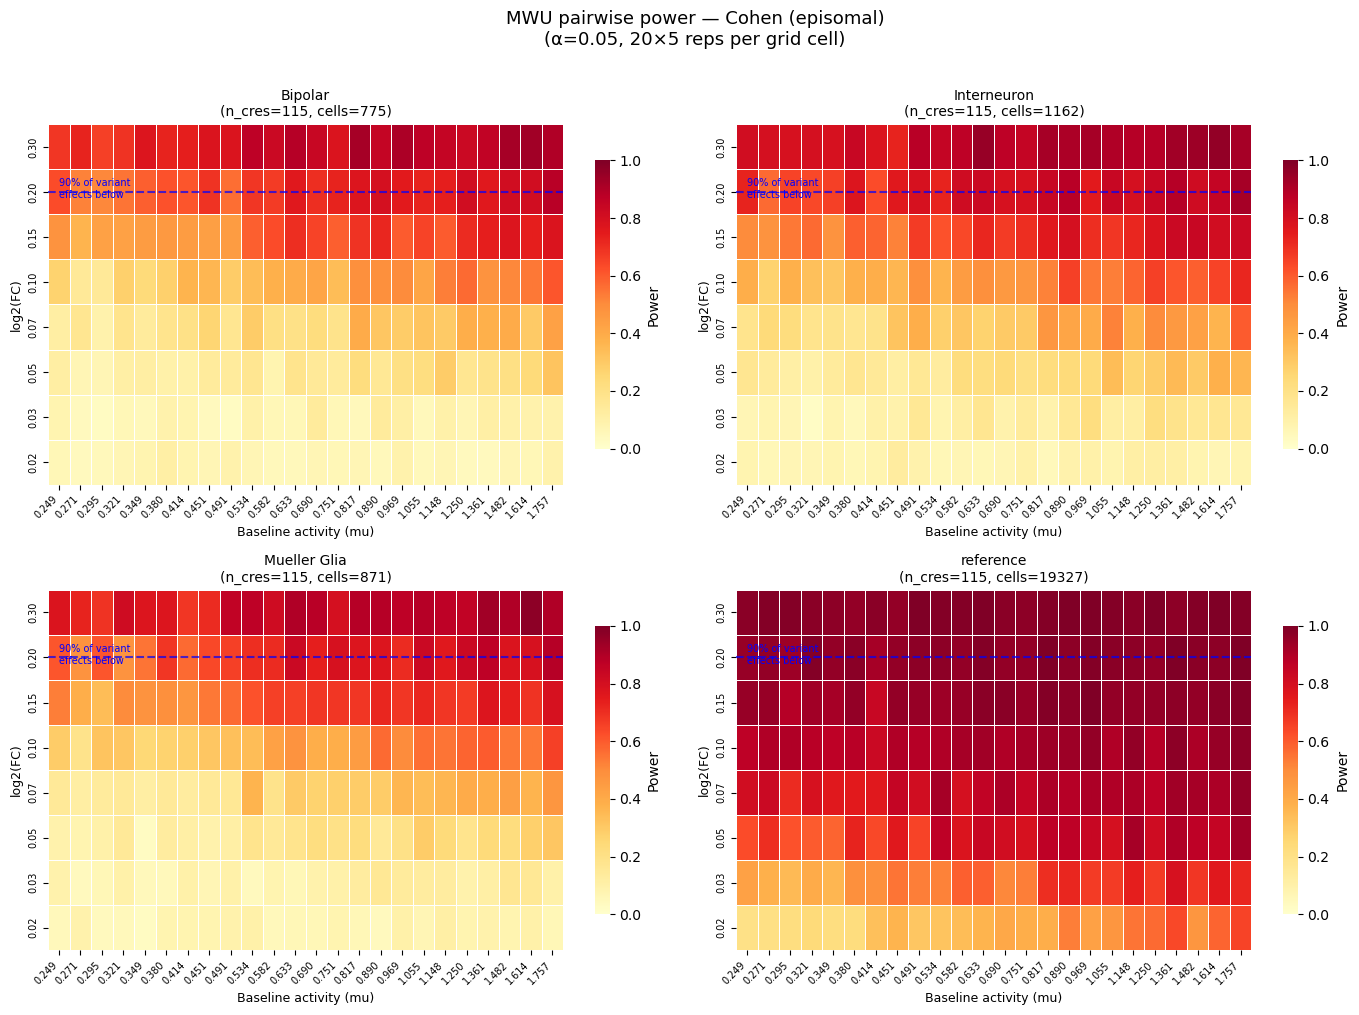

In [11]:
ncols = 2
nrows = int(np.ceil(len(cell_types) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for i, ct in enumerate(cell_types):
    ax = axes[i]
    ct_data = power_grid[power_grid["cell_type"] == ct]
    
    pivot = ct_data.pivot_table(
        index="log2_fc", columns="baseline_mu", values="power"
    )
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot[sorted(pivot.columns)]
    
    cells_ct = scm.COHEN_BOUNDS.cells_per_cell_type.get(ct, "?")
    
    sns.heatmap(
        pivot, ax=ax, vmin=0, vmax=1,
        cmap="YlOrRd", linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Power", "shrink": 0.8},
        xticklabels=[f"{x:.3f}" for x in sorted(pivot.columns)],
        yticklabels=[f"{y:.2f}" for y in pivot.index],
    )
    
    fc_vals = list(pivot.index)
    if 0.20 in fc_vals:
        y_pos = fc_vals.index(0.20) + 0.5
        ax.axhline(y=y_pos, color="blue", linestyle="--", lw=1.5, alpha=0.7)
        ax.text(0.02, y_pos - 0.3, "90% of variant\neffects below",
                transform=ax.get_yaxis_transform(), fontsize=7,
                color="blue", va="top")
    
    ax.set_title(f"{ct}\n(n_cres={n_cres}, cells={cells_ct})", fontsize=10)
    ax.set_xlabel("Baseline activity (mu)", fontsize=9)
    ax.set_ylabel("log2(FC)", fontsize=9)
    ax.tick_params(labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for j in range(len(cell_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MWU pairwise power \u2014 Cohen (episomal)\n"
             f"(\u03b1=0.05, {n_library_reps}\u00d7{n_sims} reps per grid cell)",
             fontsize=13, y=1.01)
plt.tight_layout()

svg_path = output_dir / "cohen_pairwise_power_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

## Summary: 50% power contours by cell type

Saved: output/cohen_pairwise_power_50pct_contours.svg


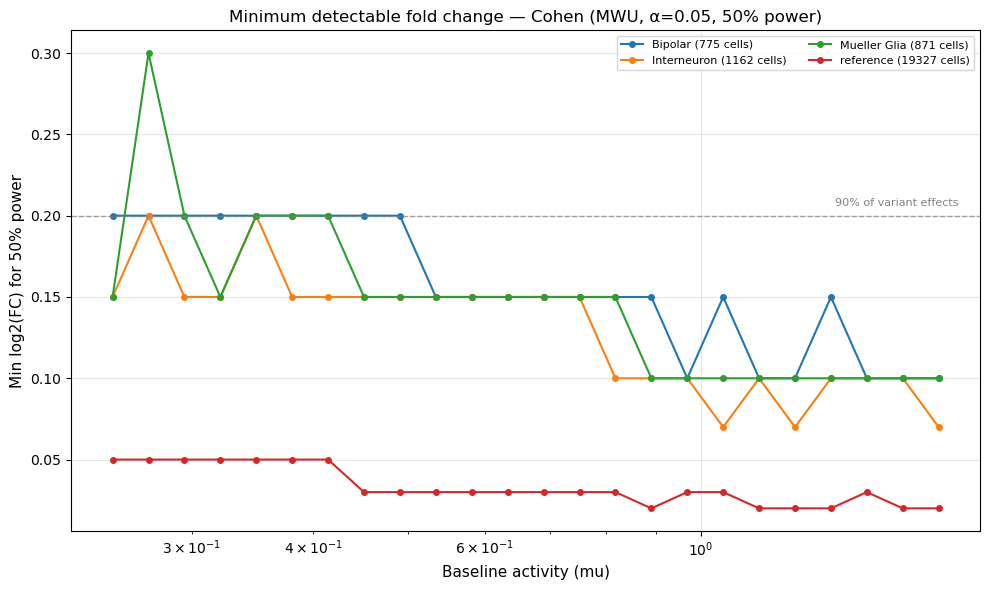

In [12]:
power_threshold = 0.50

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(cell_types))

for i, ct in enumerate(cell_types):
    ct_data = power_grid[power_grid["cell_type"] == ct]
    
    baselines = sorted(ct_data["baseline_mu"].unique())
    min_fc = []
    valid_baselines = []
    
    for bl in baselines:
        bl_data = ct_data[ct_data["baseline_mu"] == bl].sort_values("log2_fc")
        above = bl_data[bl_data["power"] >= power_threshold]
        if len(above) > 0:
            min_fc.append(above["log2_fc"].min())
            valid_baselines.append(bl)
    
    cells_ct = scm.COHEN_BOUNDS.cells_per_cell_type.get(ct, "?")
    label = f"{ct} ({cells_ct} cells)"
    
    if valid_baselines:
        ax.plot(valid_baselines, min_fc, "o-", color=palette[i],
                label=label, markersize=4, lw=1.5)
    else:
        ax.plot([], [], "o-", color=palette[i],
                label=f"{label} (no {int(power_threshold*100)}% power)")

ax.axhline(y=0.20, color="gray", linestyle="--", lw=1, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("Baseline activity (mu)", fontsize=11)
ax.set_ylabel(f"Min log2(FC) for {int(power_threshold*100)}% power", fontsize=11)
ax.set_title(f"Minimum detectable fold change — Cohen (MWU, α=0.05, "
             f"{int(power_threshold*100)}% power)", fontsize=12)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()

ax.text(ax.get_xlim()[1] * 0.95, 0.205, "90% of variant effects",
        ha="right", va="bottom", fontsize=8, color="gray")

svg_path2 = output_dir / "cohen_pairwise_power_50pct_contours.svg"
fig.savefig(svg_path2, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path2}")
plt.show()

In [13]:
client.close()
cluster.close()